In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)
coefs = []
r2_scores = []

alphas = [0, 0.1, 1, 10]
colors = ['red', 'green', 'blue', 'brown']
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_.tolist())
    y_pred = lasso.predict(X_test)
    score = r2_score(y_test, y_pred)
    r2_scores.append(score)

print("Weights: ", coefs, "\n")
print("Scores: ", r2_scores)

Weights:  [[37.904021378565965, -241.9643622992571, 542.4287586474418, 347.7038438652998, -931.4888381960012, 518.0622710331819, 163.41997955248303, 275.31790051957216, 736.1988559877807, 48.67065746354245], [0.0, -152.6647792342513, 552.6977752929224, 303.36515790671865, -81.365006635376, -0.0, -229.25577638583215, 0.0, 447.91952518413837, 29.64261703820772], [0.0, -0.0, 413.4318479231423, 34.83051518060981, 0.0, 0.0, -0.0, 0.0, 258.15289363124595, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0]] 

Scores:  [0.45260276304361946, 0.4718547867276227, 0.3575918767219115, -0.011962984778542296]


D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.063e+05, tolerance: 2.145e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.e

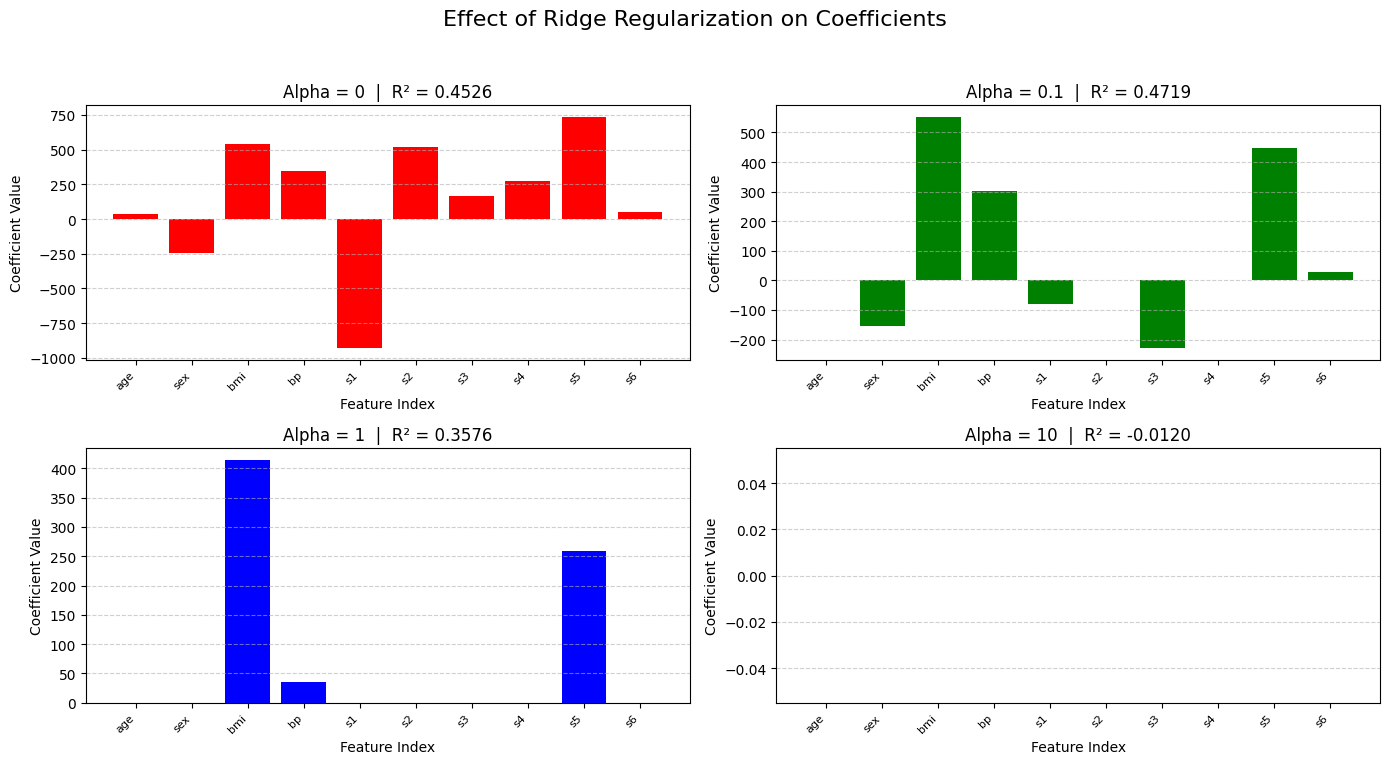

In [3]:
# Plotting: 2 rows x 2 cols
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Effect of Ridge Regularization on Coefficients", fontsize=16)

# Flatten axes for easy indexing
axes_flat = axes.flatten()

for idx, ax in enumerate(axes_flat):
    # bar plot of coefficients for this alpha
    ax.bar(np.arange(len(coefs[idx])), coefs[idx], color=colors[idx])
    ax.set_title(f"Alpha = {alphas[idx]}  |  R² = {r2_scores[idx]:.4f}", fontsize=12)
    ax.set_xlabel("Feature Index", fontsize=10)
    ax.set_ylabel("Coefficient Value", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    # set feature names as x-ticks (optional: change to indices if labels crowd)
    ax.set_xticks(np.arange(len(data.feature_names)))
    ax.set_xticklabels(data.feature_names, rotation=45, ha='right', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **<font color="green">2. Higher coefficients are affected more.</font>**
- Higher impact on the higers cofficients.

In [4]:
# ================================================
# Lasso Regression: Coefficient Paths Visualization
# ================================================
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============ Load Data ============
data = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=2
)

# ============ Define Alphas ============
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# ============ Compute Coefficients ============
coefs = []
for alpha in alphas:
    reg = Lasso(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())

# Convert to DataFrame
input_array = np.array(coefs)
coef_df = pd.DataFrame(input_array, columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.e

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.551989,561.220669,153.893104,126.731395,861.126997,52.421122
0.0001,-9.069064,-205.329406,516.789418,340.532379,-888.660904,555.958584,150.593655,125.450143,858.645541,52.380294
0.0010,-8.262770,-204.205364,517.650073,339.743901,-826.663603,508.617395,120.908607,113.921773,836.320753,52.012849
0.0100,-1.359721,-192.937180,526.356514,332.641101,-430.226975,191.295480,-44.034913,68.988987,688.396028,47.940616
0.1000,0.000000,-113.969928,526.744396,292.628472,-82.693681,-0.000000,-152.685338,0.000000,551.080291,7.170992
1.0000,0.000000,0.000000,363.885742,27.273163,0.000000,0.000000,-0.000000,0.000000,336.137262,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
1000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.e

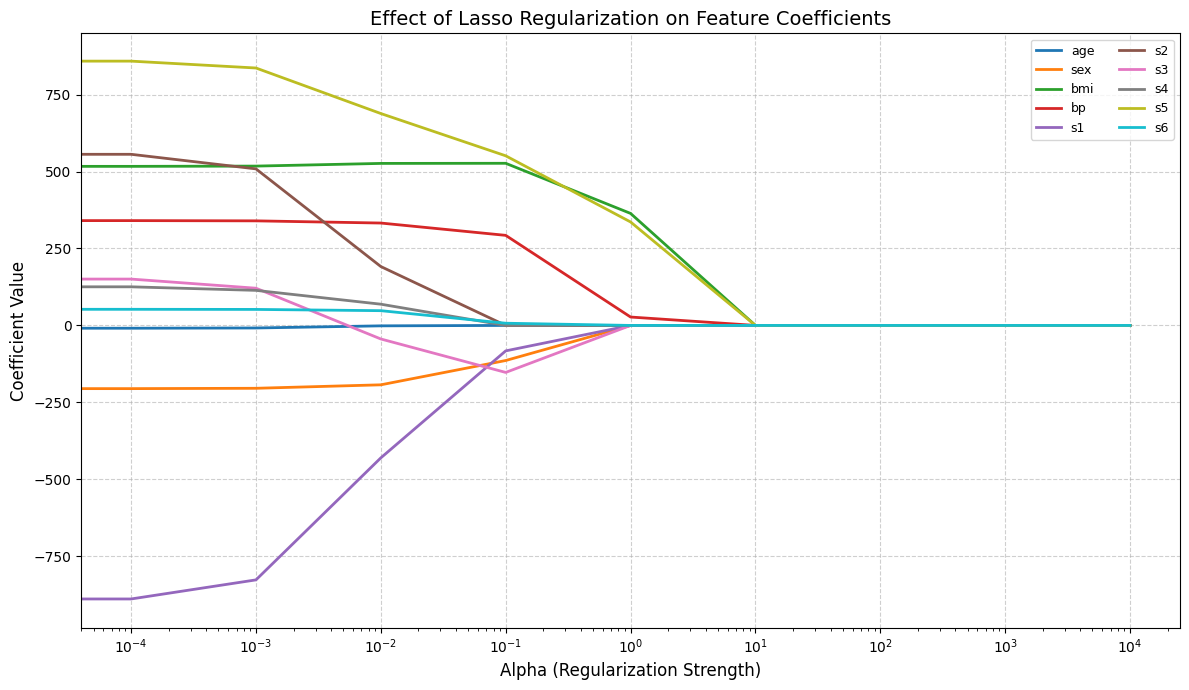

In [5]:
# ================================================
# Lasso Regression: Coefficient Paths Visualization
# ================================================
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============ Load Data ============
data = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=2
)

# ============ Define Alphas ============
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# ============ Compute Coefficients ============
coefs = []
for alpha in alphas:
    reg = Lasso(alpha=alpha)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())

# Convert to DataFrame
input_array = np.array(coefs)
coef_df = pd.DataFrame(input_array, columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha', inplace=True)

# ============ Plotting ============
plt.figure(figsize=(12, 7))
for feature in data.feature_names:
    plt.plot(coef_df.index, coef_df[feature], label=feature, linewidth=2)

plt.xscale('log')  # Log scale for better alpha visualization
plt.xlabel("Alpha (Regularization Strength)", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.title("Effect of Lasso Regularization on Feature Coefficients", fontsize=14)
plt.legend(loc='best', fontsize=9, ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## **<font color="green">3. Bias Variance Trade-off</font>**
- ![](../img/bias-varianec-trade-off1-Lasso-Regression.webp)
- ![](../img/under-over-fitting.png)

### ***<font color="blue">Degree 6</font>***

D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.934e+00, tolerance: 5.073e-03
  model = cd_fast.enet_coordinate_descent(
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.130e+01, tolerance: 5.073e-03
  model = cd_fast.enet_coordinate_descent(
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality 

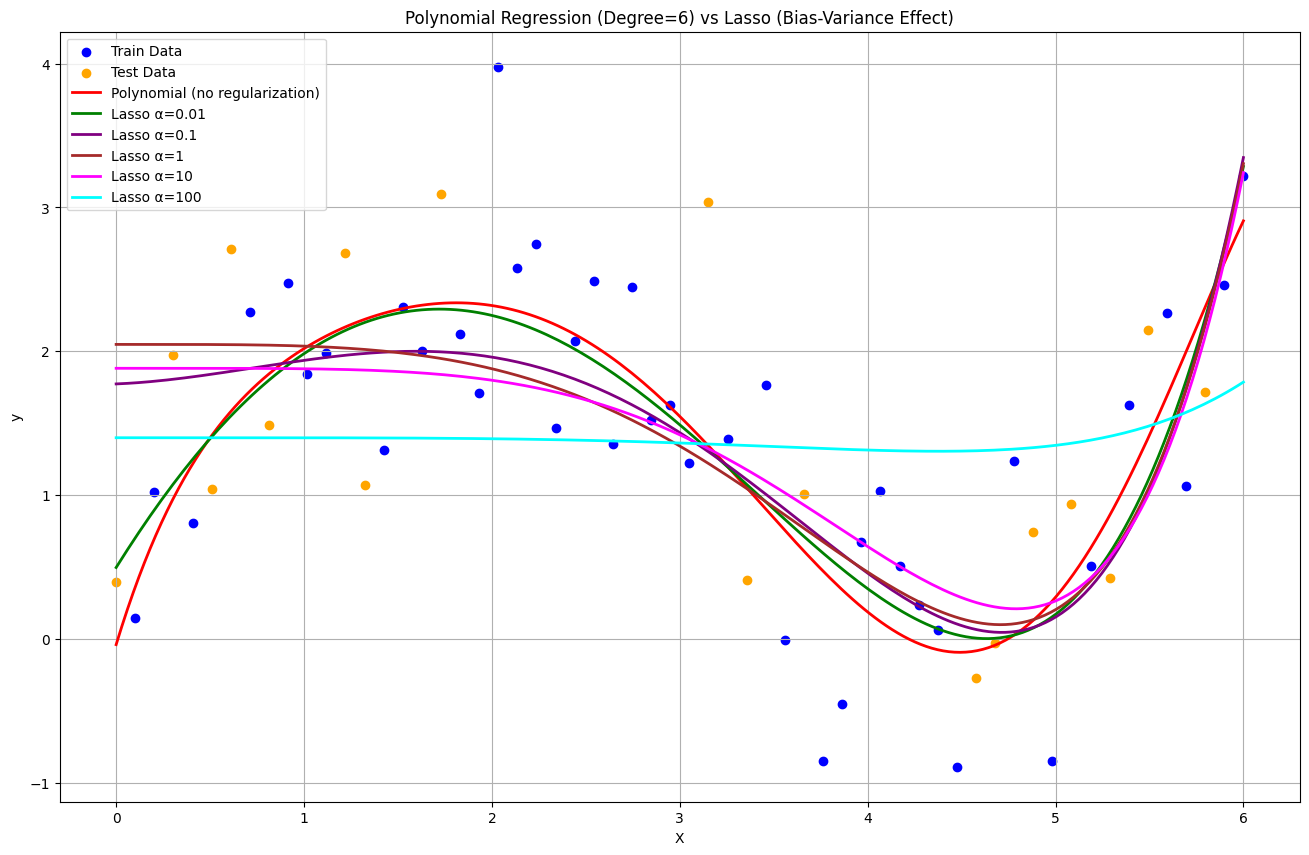

No Regularization         | Train MSE: 0.4069 | Test MSE: 0.5621
Lasso α=0.01              | Train MSE: 0.4273 | Test MSE: 0.5815
Lasso α=0.1               | Train MSE: 0.5527 | Test MSE: 0.6735
Lasso α=1                 | Train MSE: 0.6153 | Test MSE: 0.7407
Lasso α=10                | Train MSE: 0.6259 | Test MSE: 0.7033
Lasso α=100               | Train MSE: 1.1153 | Test MSE: 0.9928


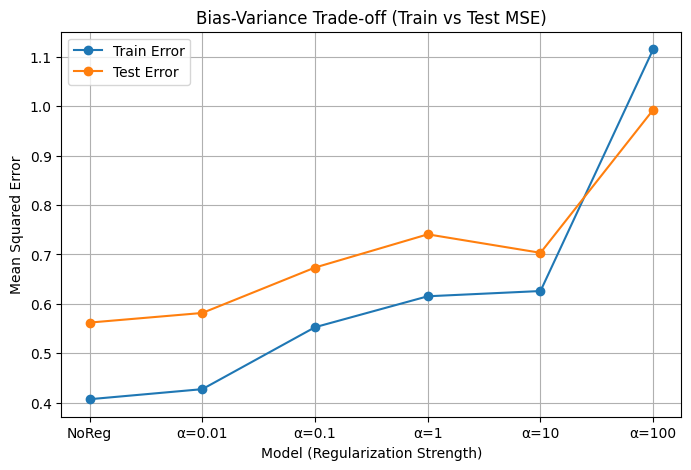

In [8]:
# polynomial_lasso_bias_variance.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==================================
# Step 1: Create synthetic dataset
# ==================================
np.random.seed(42)
X = np.linspace(0, 6, 60)[:, np.newaxis]
y = 2 * np.sin(X) + 0.5 * X + np.random.randn(60, 1) * 0.8

# Split train/test (to study bias-variance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==================================
# Step 2: Polynomial regression (degree=6)
# ==================================
degree = 6
poly_reg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_reg.fit(X_train, y_train)

# ==================================
# Step 3: Ridge regression for different alphas
# ==================================
alphas = [0.01, 0.1, 1, 10, 100]
lasso_models = [make_pipeline(PolynomialFeatures(degree), Lasso(alpha=a)) for a in alphas]
for model in lasso_models:
    model.fit(X_train, y_train)

# ==================================
# Step 4: Visualize model fits
# ==================================
X_plot = np.linspace(0, 6, 200)[:, np.newaxis]
plt.figure(figsize=(16, 10))
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='orange', label='Test Data')

# Plot Polynomial Regression
plt.plot(X_plot, poly_reg.predict(X_plot), color='red', linewidth=2, label='Polynomial (no regularization)')

# Plot Ridge Regression
colors = ['green', 'purple', 'brown', 'magenta', 'cyan']
for alpha, model, color in zip(alphas, lasso_models, colors):
    y_pred = model.predict(X_plot)
    plt.plot(X_plot, y_pred, color=color, linewidth=2, label=f'Lasso α={alpha}')

plt.title(f'Polynomial Regression (Degree={degree}) vs Lasso (Bias-Variance Effect)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# ==================================
# Step 5: Compute train/test MSE
# ==================================
models = [('No Regularization', poly_reg)] + [(f'Lasso α={a}', m) for a, m in zip(alphas, lasso_models)]

train_errors = []
test_errors = []

for name, model in models:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    print(f"{name:<25} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")

# ==================================
# Step 6: Plot bias-variance trade-off
# ==================================
plt.figure(figsize=(8, 5))
plt.plot(['NoReg'] + [f'α={a}' for a in alphas], train_errors, marker='o', label='Train Error')
plt.plot(['NoReg'] + [f'α={a}' for a in alphas], test_errors, marker='o', label='Test Error')
plt.title('Bias-Variance Trade-off (Train vs Test MSE)')
plt.xlabel('Model (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()


### ***<font color="blue">Degree 16</font>***

D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.504e+01, tolerance: 5.910e-03
  model = cd_fast.enet_coordinate_descent(
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.609e+01, tolerance: 5.910e-03
  model = cd_fast.enet_coordinate_descent(
D:\Study\AI\machineLearning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality 

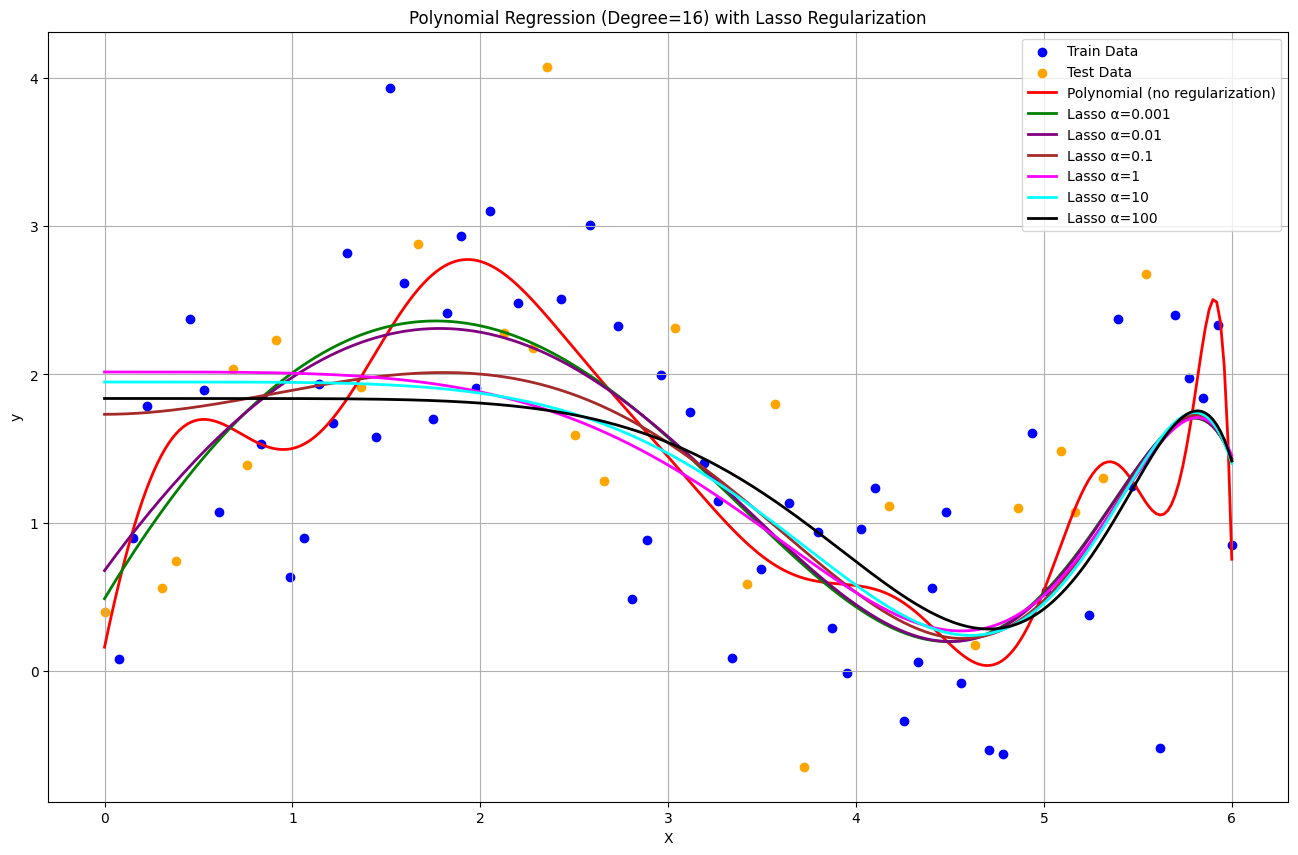

No Regularization         | Train MSE: 0.4384 | Test MSE: 0.5845
Lasso α=0.001             | Train MSE: 0.5319 | Test MSE: 0.5259
Lasso α=0.01              | Train MSE: 0.5314 | Test MSE: 0.5422
Lasso α=0.1               | Train MSE: 0.6011 | Test MSE: 0.7467
Lasso α=1                 | Train MSE: 0.6647 | Test MSE: 0.8746
Lasso α=10                | Train MSE: 0.6543 | Test MSE: 0.8542
Lasso α=100               | Train MSE: 0.6643 | Test MSE: 0.8546


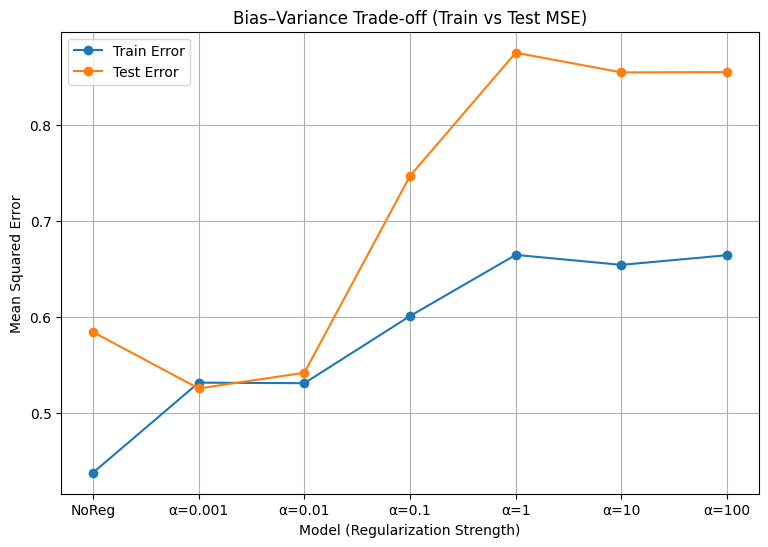

In [9]:
# polynomial_ridge_bias_variance_deg16.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ==================================
# Step 1: Create synthetic dataset
# ==================================
np.random.seed(42)
X = np.linspace(0, 6, 80)[:, np.newaxis]
y = 2 * np.sin(X) + 0.5 * X + np.random.randn(80, 1) * 0.8

# Split data into train/test (for bias–variance analysis)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==================================
# Step 2: Define high-degree polynomial regression (degree=16)
# ==================================
degree = 16
poly_reg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_reg.fit(X_train, y_train)

# ==================================
# Step 3: Ridge regression with different alphas
# ==================================
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
lasso_models = [make_pipeline(PolynomialFeatures(degree), Lasso(alpha=a)) for a in alphas]
for model in lasso_models:
    model.fit(X_train, y_train)

# ==================================
# Step 4: Visualize fits
# ==================================
X_plot = np.linspace(0, 6, 300)[:, np.newaxis]

plt.figure(figsize=(16, 10))
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='orange', label='Test Data')

# Plot plain polynomial regression
plt.plot(X_plot, poly_reg.predict(X_plot), color='red', linewidth=2, label='Polynomial (no regularization)')

# Plot ridge models
colors = ['green', 'purple', 'brown', 'magenta', 'cyan', 'black']
for alpha, model, color in zip(alphas, lasso_models, colors):
    y_pred = model.predict(X_plot)
    plt.plot(X_plot, y_pred, color=color, linewidth=2, label=f'Lasso α={alpha}')

plt.title(f'Polynomial Regression (Degree={degree}) with Lasso Regularization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# ==================================
# Step 5: Compute train/test MSE
# ==================================
models = [('No Regularization', poly_reg)] + [(f'Lasso α={a}', m) for a, m in zip(alphas, lasso_models)]

train_errors = []
test_errors = []

for name, model in models:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    print(f"{name:<25} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")

# ==================================
# Step 6: Plot Bias–Variance Trade-off
# ==================================
plt.figure(figsize=(9, 6))
plt.plot(['NoReg'] + [f'α={a}' for a in alphas], train_errors, marker='o', label='Train Error')
plt.plot(['NoReg'] + [f'α={a}' for a in alphas], test_errors, marker='o', label='Test Error')
plt.title('Bias–Variance Trade-off (Train vs Test MSE)')
plt.xlabel('Model (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()


### ***<font color="blue">Effect of Bias Variance Plots</font>***

X_train.shape = (80, 1), X_test.shape = (20, 1)
y_train.shape = (80,), y_test.shape = (20,)


Alpha sweep: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.96it/s]



Best alpha (min avg expected MSE) = 0.303030, loss = 1.432132


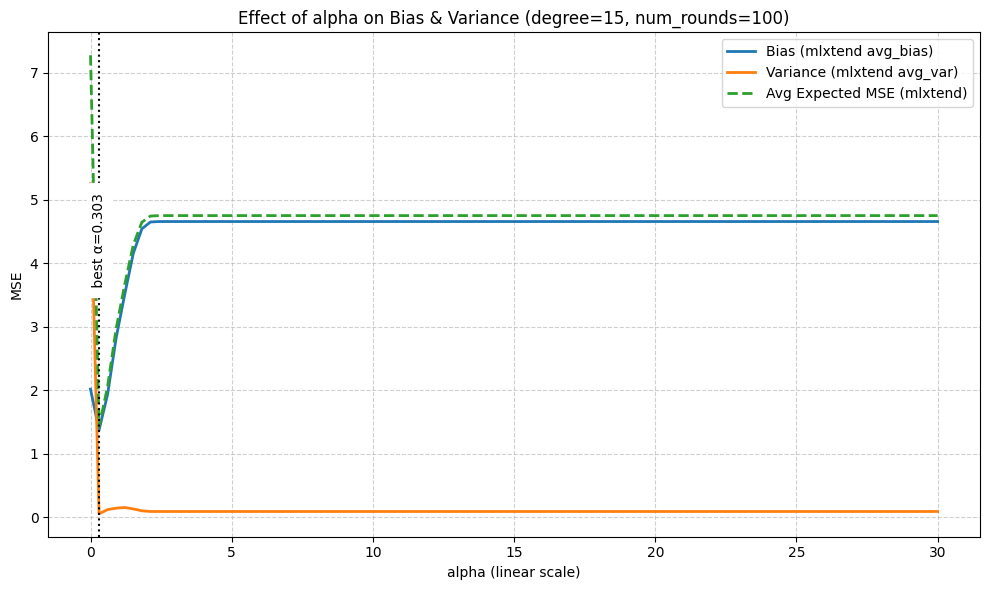


Structured Summary Table (selected α values):


,alpha,Avg_Expected_Loss,Bias,Variance
0,0.00000,7.271956,2.017980,5.253976
1,4.24242,4.749216,4.655763,0.093453
2,8.48485,4.749216,4.655763,0.093453
3,12.72727,4.749216,4.655763,0.093453
4,17.27273,4.749216,4.655763,0.093453
5,21.51515,4.749216,4.655763,0.093453
6,25.75758,4.749216,4.655763,0.093453
7,30.00000,4.749216,4.655763,0.093453


In [17]:
# lasso_bias_variance_sweep.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso, LinearRegression
from mlxtend.evaluate import bias_variance_decomp

# ---------------------------
# Optional: quiet noisy numeric warnings
# ---------------------------
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Ill-conditioned matrix")
warnings.filterwarnings("ignore", message="Singular matrix")

# ---------------------------
# Data: user-provided style
# ---------------------------
np.random.seed(2)
m = 100
X = 5 * np.random.rand(m, 1) - 2            # uniform in [-2, 3]
y = 0.7 * X**2 - 2 * X + 3 + np.random.randn(m, 1)  # shape (m,1)

# reshape/flatten for sklearn (mlxtend expects 1d y)
X = X.reshape(-1, 1)
y = y.ravel()

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

print(f"X_train.shape = {X_train.shape}, X_test.shape = {X_test.shape}")
print(f"y_train.shape = {y_train.shape}, y_test.shape = {y_test.shape}")

# ---------------------------
# Sweep alphas and run bias-variance decomposition
# ---------------------------
degree = 15
# Avoid exact zero floating issues by including 0.0 explicitly
alphas = np.linspace(0.0, 30.0, 100)

# NOTE: mlxtend's bias_variance_decomp uses repeated resampling; this can be slow.
num_rounds = 100   # keep as you requested; reduce to 30-50 if it's too slow
random_seed = 123

loss_list = []
bias_list = []
var_list = []

# Use tqdm for progress display (helpful during long runs)
for alpha in tqdm(alphas, desc="Alpha sweep"):
    # When alpha == 0 we use LinearRegression (no L1 penalty).
    if float(alpha) == 0.0:
        estimator = make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            StandardScaler(),
            LinearRegression()
        )
    else:
        estimator = make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            StandardScaler(),
            Lasso(alpha=float(alpha), max_iter=20000, tol=1e-4)
        )

    # Perform bias-variance decomposition (mlxtend)
    try:
        avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
            estimator,
            X_train, y_train,
            X_test, y_test,
            loss='mse',
            num_rounds=num_rounds,
            random_seed=random_seed
        )
    except Exception as e:
        # If one alpha fails (e.g., convergence issues), capture and continue
        print(f"Warning: alpha={alpha:.6f} failed: {e}. Appending np.nan.")
        avg_expected_loss, avg_bias, avg_var = np.nan, np.nan, np.nan

    loss_list.append(avg_expected_loss)
    bias_list.append(avg_bias)
    var_list.append(avg_var)

# Convert to arrays
loss_arr = np.array(loss_list, dtype=float)
bias_arr = np.array(bias_list, dtype=float)
var_arr = np.array(var_list, dtype=float)

# Mask NaNs when searching for min
valid_idx = ~np.isnan(loss_arr)
if valid_idx.any():
    best_idx = np.nanargmin(loss_arr)
    best_alpha = alphas[best_idx]
    print(f"\nBest alpha (min avg expected MSE) = {best_alpha:.6f}, loss = {loss_arr[best_idx]:.6f}")
else:
    best_alpha = None
    print("\nNo valid results found (all NaNs).")

# ---------------------------
# Plot results
# ---------------------------
plt.figure(figsize=(10, 6))
plt.plot(alphas, bias_arr, label='Bias (mlxtend avg_bias)', linewidth=2)
plt.plot(alphas, var_arr, label='Variance (mlxtend avg_var)', linewidth=2)
plt.plot(alphas, loss_arr, label='Avg Expected MSE (mlxtend)', linewidth=2, linestyle='--')

if best_alpha is not None:
    plt.axvline(best_alpha, color='k', linestyle=':', linewidth=1.5)
    # place the annotation near 60% of max (safely handle NaNs)
    finite_max = np.nanmax(loss_arr) if np.isfinite(np.nanmax(loss_arr)) else 1.0
    ypos = finite_max * 0.6
    plt.text(best_alpha, ypos, f' best α={best_alpha:.3f} ', rotation=90, va='center',
             ha='center', backgroundcolor='white')

plt.xlabel('alpha (linear scale)')
plt.ylabel('MSE')
plt.title(f'Effect of alpha on Bias & Variance (degree={degree}, num_rounds={num_rounds})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------
# Print a structured summary table for selected alphas
# ---------------------------
print("\nStructured Summary Table (selected α values):")
sample_idx = np.round(np.linspace(0, len(alphas) - 1, 8)).astype(int)

summary_df = pd.DataFrame({
    "alpha": [float(alphas[i]) for i in sample_idx],
    "Avg_Expected_Loss": [float(loss_arr[i]) if not np.isnan(loss_arr[i]) else np.nan for i in sample_idx],
    "Bias": [float(bias_arr[i]) if not np.isnan(bias_arr[i]) else np.nan for i in sample_idx],
    "Variance": [float(var_arr[i]) if not np.isnan(var_arr[i]) else np.nan for i in sample_idx]
})

summary_df = summary_df.round({
    "alpha": 5,
    "Avg_Expected_Loss": 6,
    "Bias": 6,
    "Variance": 6
})

# Print the table to stdout
summary_df.head(10)


## **<font color="green">4. Effect of Regularization on Loss Function</font>**

X shape: (100, 1)
y shape: (100,)

=== Ordinary Linear Regression ===
Coefficient (slope): [27.82809103]
Intercept: -2.29474455867698
R^2 score: 0.7035

Using fixed intercept = -2.2947 when plotting manual L1 losses.
alpha=    0 -> argmin slope m ≈ 27.8264, loss ≈ 28342.276
alpha=  100 -> argmin slope m ≈ 27.2461, loss ≈ 31096.417
alpha=  200 -> argmin slope m ≈ 26.6658, loss ≈ 33793.217
alpha=  500 -> argmin slope m ≈ 24.9250, loss ≈ 41539.576
alpha=  800 -> argmin slope m ≈ 23.2566, loss ≈ 48769.620
alpha= 1000 -> argmin slope m ≈ 22.0960, loss ≈ 53302.942
alpha= 2000 -> argmin slope m ≈ 16.3657, loss ≈ 72528.761
alpha= 2500 -> argmin slope m ≈ 13.4642, loss ≈ 79991.158
alpha= 3000 -> argmin slope m ≈ 10.6353, loss ≈ 86019.734

=== sklearn Lasso fits (comparison) ===
sklearn Lasso alpha=0.0010 -> slope=27.826940, intercept=-2.294677
sklearn Lasso alpha=0.0100 -> slope=27.816576, intercept=-2.294072
sklearn Lasso alpha=0.1000 -> slope=27.712943, intercept=-2.288019
sklearn Lasso alpha

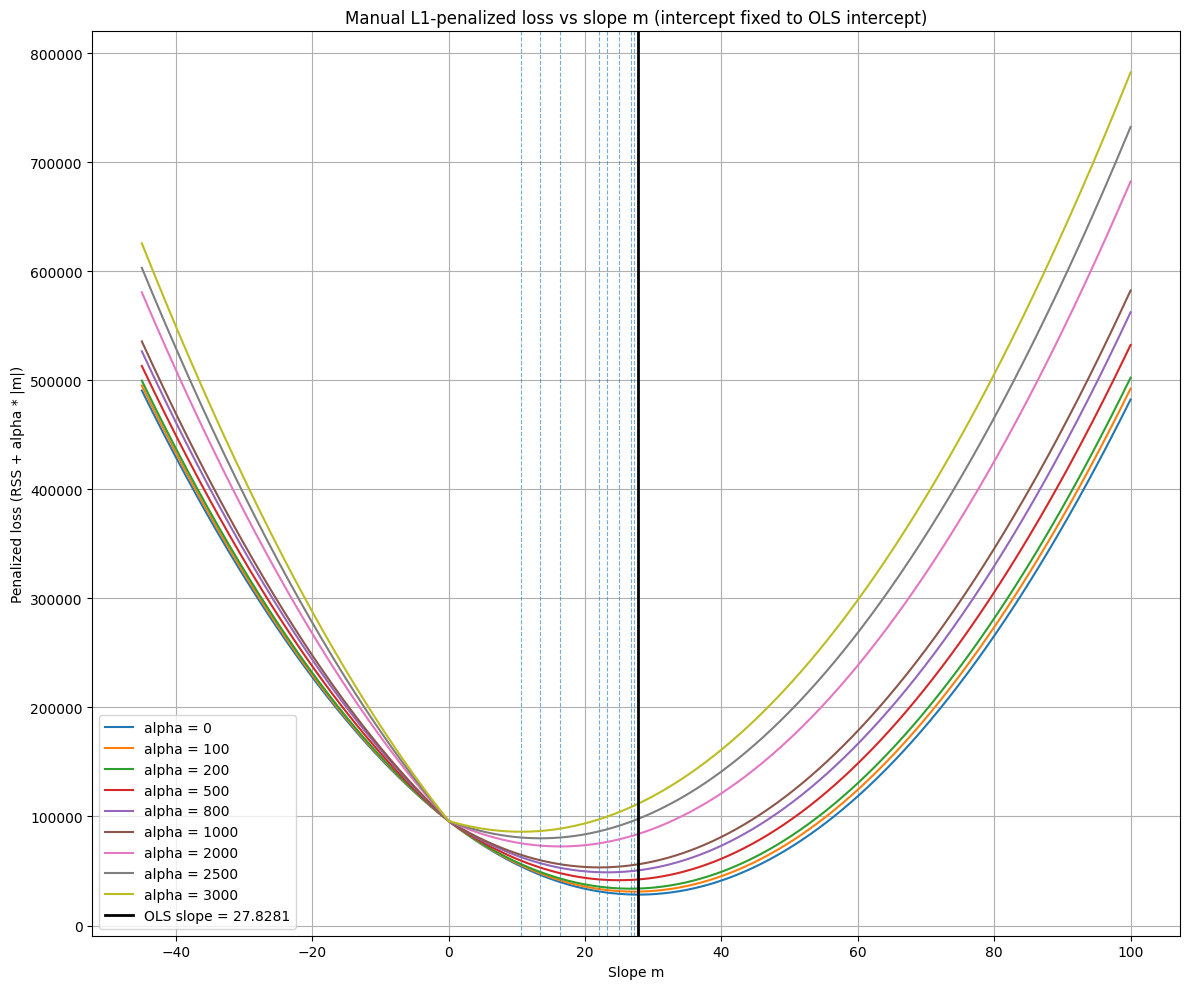

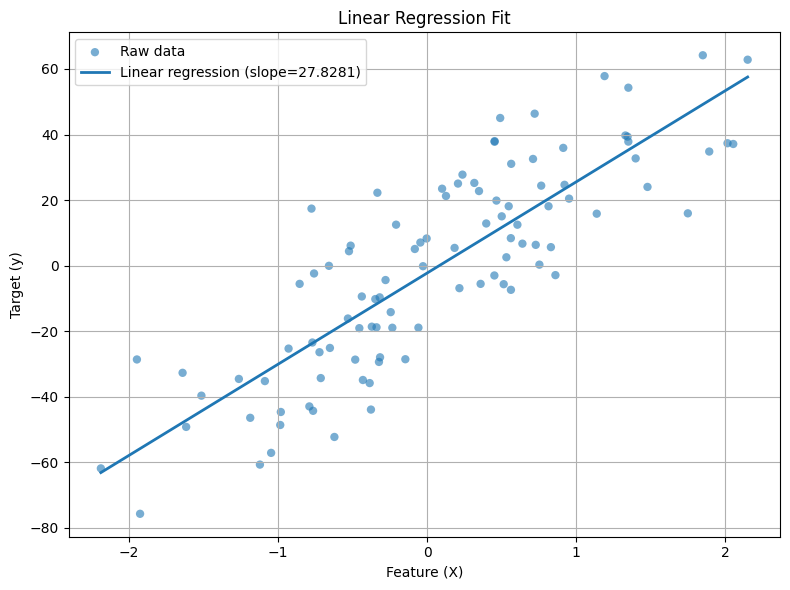

In [21]:
# fixed_regression_with_lasso_analysis.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore")  # keep plot output clean for demo

# -----------------------
# Data generation & checks
# -----------------------
X, y = make_regression(n_samples=100,
                       n_features=1,
                       n_informative=1,
                       n_targets=1,
                       noise=20,
                       random_state=13)

# Basic sanity checks
assert X is not None and y is not None
assert X.ndim == 2 and X.shape[1] == 1, "X must be shape (n_samples, 1)"
assert y.ndim == 1, "y must be a 1d array"

print("X shape:", X.shape)   # (100, 1)
print("y shape:", y.shape)   # (100,)

# -----------------------
# Fit ordinary least squares
# -----------------------
lr = LinearRegression()
lr.fit(X, y)

print("\n=== Ordinary Linear Regression ===")
print("Coefficient (slope):", lr.coef_)    # array of shape (1,)
print("Intercept:", lr.intercept_)

# Predictions and score
y_pred = lr.predict(X)
r2 = r2_score(y, y_pred)
print(f"R^2 score: {r2:.4f}")

# Sort X for neat plotting of the regression line
sorted_idx = np.argsort(X[:, 0])
X_sorted = X[sorted_idx]
y_pred_sorted = lr.predict(X_sorted)

# -----------------------
# Manual L1-penalized loss vs slope (m)
# -----------------------
# We'll keep the intercept fixed to the OLS intercept and vary slope m.
intercept_fixed = float(lr.intercept_)
print(f"\nUsing fixed intercept = {intercept_fixed:.4f} when plotting manual L1 losses.")

alphas = [0, 100, 200, 500, 800, 1000, 2000, 2500, 3000]   # same as user's list
m_values = np.linspace(-45, 100, 2000)         # dense grid for smooth curves

# Compute losses for each alpha while varying slope m (keep intercept fixed)
loss_curves = {}
for alpha in alphas:
    losses = []
    for m in m_values:
        preds = m * X.ravel() + intercept_fixed
        residual_sum_squares = np.sum((y - preds) ** 2)
        l1_penalty = alpha * abs(m)                # L1 on slope only
        loss = residual_sum_squares + l1_penalty
        losses.append(loss)
    loss_curves[alpha] = np.array(losses)

# Find minima (slope that minimizes the penalized loss) for each alpha
minima = {}
for alpha in alphas:
    idx_min = np.argmin(loss_curves[alpha])
    m_min = m_values[idx_min]
    minima[alpha] = (m_min, loss_curves[alpha][idx_min])
    print(f"alpha={alpha:5d} -> argmin slope m ≈ {m_min:.4f}, loss ≈ {loss_curves[alpha][idx_min]:.3f}")

# -----------------------
# Plot manual loss curves
# -----------------------
plt.figure(figsize=(12, 10))
for alpha in alphas:
    plt.plot(m_values, loss_curves[alpha], label=f"alpha = {alpha}")
    m_min, _ = minima[alpha]
    plt.axvline(m_min, linestyle='--', linewidth=0.8, alpha=0.6)  # mark minimum slope
# Mark the OLS slope
ols_slope = float(lr.coef_[0])
plt.axvline(ols_slope, color='k', linewidth=2, label=f"OLS slope = {ols_slope:.4f}")
plt.xlabel("Slope m")
plt.ylabel("Penalized loss (RSS + alpha * |m|)")
plt.title("Manual L1-penalized loss vs slope m (intercept fixed to OLS intercept)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# -----------------------
# Scatter + regression line
# -----------------------
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.6, label="Raw data", edgecolors='none')
plt.plot(X_sorted, y_pred_sorted, linewidth=2, label=f"Linear regression (slope={ols_slope:.4f})", linestyle='-')
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Linear Regression Fit")
plt.grid(linestyle='-')
plt.legend()
plt.tight_layout()

# -----------------------
# Fit sklearn Lasso models (for comparison)
# -----------------------
# Note: sklearn Lasso's alpha is not on the same scale as our manual 'alpha' above.
# We'll fit several Lasso alphas to show coefficient shrinkage.
lasso_alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
print("\n=== sklearn Lasso fits (comparison) ===")
for a in lasso_alphas:
    l = Lasso(alpha=a, fit_intercept=True, max_iter=10000)
    l.fit(X, y)
    print(f"sklearn Lasso alpha={a:6.4f} -> slope={l.coef_[0]:.6f}, intercept={l.intercept_:.6f}")

# Show plots
plt.show()


X shape: (100, 1)
y shape: (100,)

=== Ordinary Linear Regression ===
Coefficient (slope): [27.82809103]
Intercept: -2.29474455867698
R^2 score: 0.7035

Using fixed intercept = -2.2947 when plotting manual losses.
[L1] alpha=    0 -> argmin slope m ≈ 27.8143, loss ≈ 28342.292
[L1] alpha=  100 -> argmin slope m ≈ 27.2341, loss ≈ 31096.447
[L1] alpha=  200 -> argmin slope m ≈ 26.7022, loss ≈ 33793.236
[L1] alpha=  500 -> argmin slope m ≈ 24.9617, loss ≈ 41539.465
[L1] alpha=  800 -> argmin slope m ≈ 23.2211, loss ≈ 48769.628
[L1] alpha= 1000 -> argmin slope m ≈ 22.1090, loss ≈ 53302.963
[L1] alpha= 2000 -> argmin slope m ≈ 16.3555, loss ≈ 72528.758
[L1] alpha= 2500 -> argmin slope m ≈ 13.5028, loss ≈ 79991.108
[L1] alpha= 3000 -> argmin slope m ≈ 10.6019, loss ≈ 86019.763
[L2] alpha=    0 -> argmin slope m ≈ 27.8143, loss ≈ 28342.292
[L2] alpha=  100 -> argmin slope m ≈ 12.9710, loss ≈ 64411.852
[L2] alpha=  200 -> argmin slope m ≈ 8.4261, loss ≈ 75362.253
[L2] alpha=  500 -> argmin slop

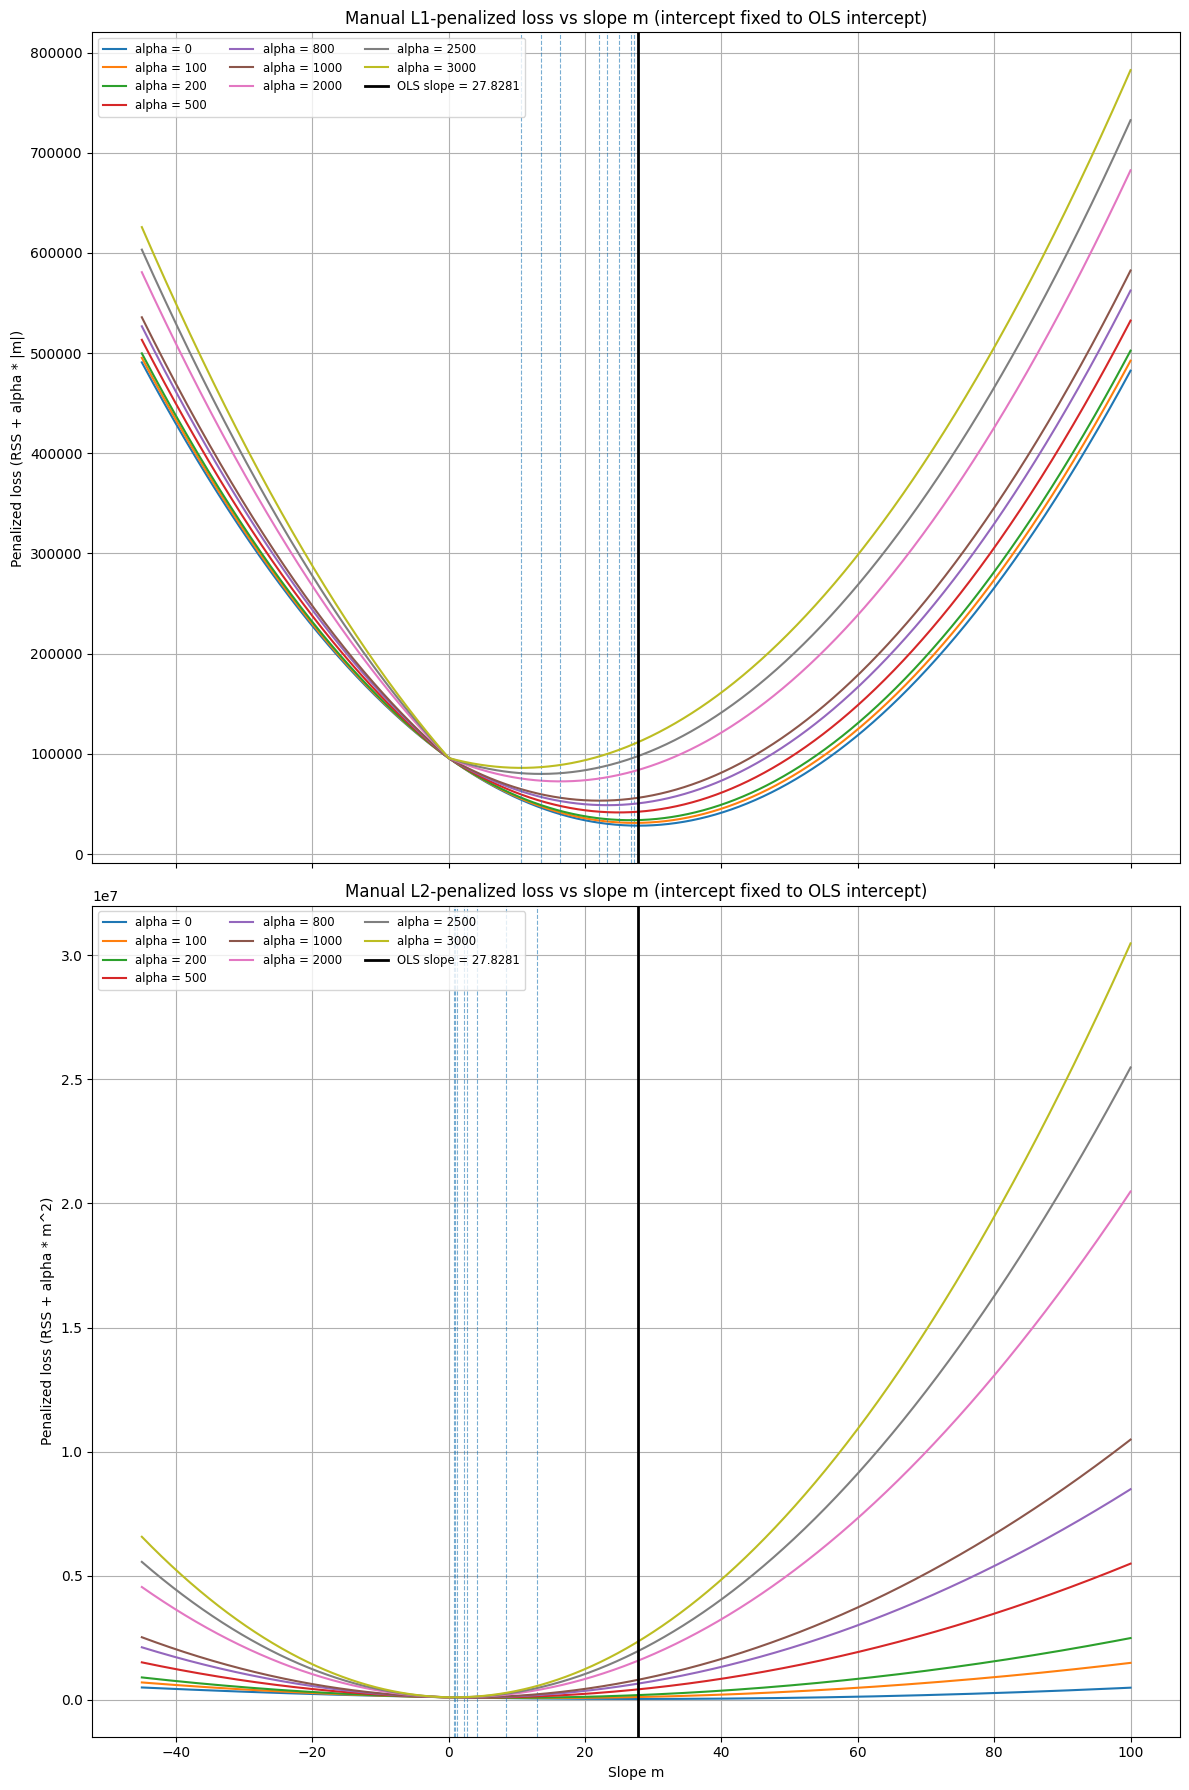

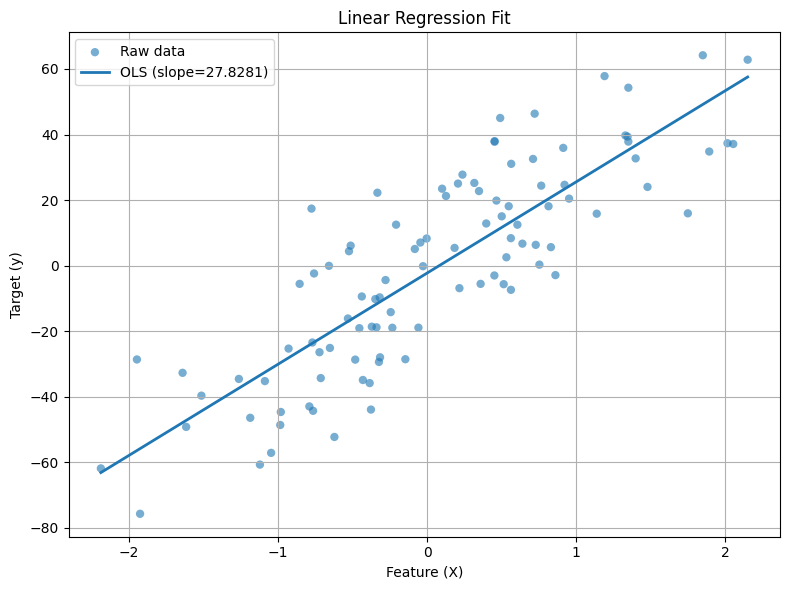

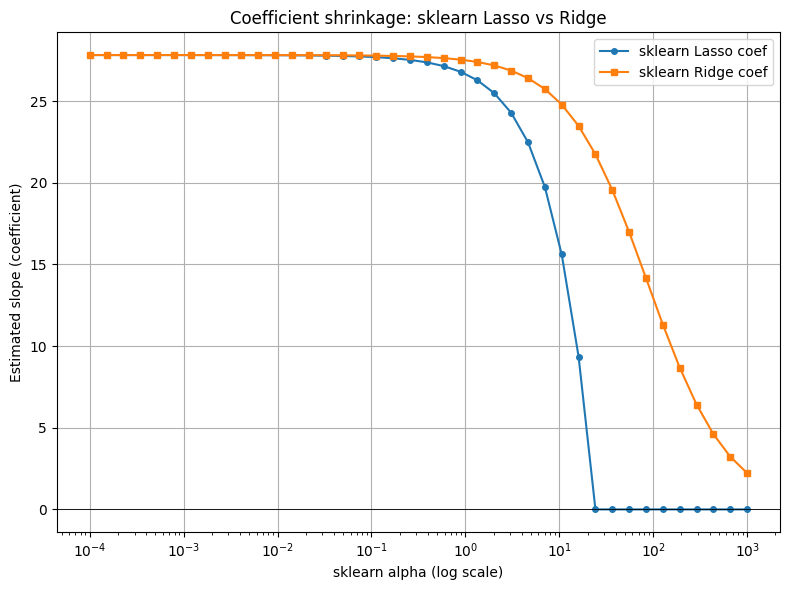

In [26]:
# fixed_regression_with_lasso_ridge_analysis.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore")  # keep plot output clean for demo

# -----------------------
# Data generation & checks
# -----------------------
X, y = make_regression(n_samples=100,
                       n_features=1,
                       n_informative=1,
                       n_targets=1,
                       noise=20,
                       random_state=13)

# Basic sanity checks
assert X is not None and y is not None
assert X.ndim == 2 and X.shape[1] == 1, "X must be shape (n_samples, 1)"
assert y.ndim == 1, "y must be a 1d array"

print("X shape:", X.shape)   # (100, 1)
print("y shape:", y.shape)   # (100,)

# -----------------------
# Fit ordinary least squares
# -----------------------
lr = LinearRegression()
lr.fit(X, y)

print("\n=== Ordinary Linear Regression ===")
print("Coefficient (slope):", lr.coef_)    # array of shape (1,)
print("Intercept:", lr.intercept_)

# Predictions and score
y_pred = lr.predict(X)
r2 = r2_score(y, y_pred)
print(f"R^2 score: {r2:.4f}")

# Sort X for neat plotting of the regression line
sorted_idx = np.argsort(X[:, 0])
X_sorted = X[sorted_idx]
y_pred_sorted = lr.predict(X_sorted)
ols_slope = float(lr.coef_[0])
intercept_fixed = float(lr.intercept_)
print(f"\nUsing fixed intercept = {intercept_fixed:.4f} when plotting manual losses.")

# -----------------------
# Parameters for manual loss sweeps
# -----------------------
manual_alphas = [0, 100, 200, 500, 800, 1000, 2000, 2500, 3000]
m_values = np.linspace(-45, 100, 3000)  # dense grid for smooth curves

# -----------------------
# Manual L1-penalized loss vs slope (m)  -> penalty = alpha * |m|
# -----------------------
loss_curves_l1 = {}
minima_l1 = {}
for alpha in manual_alphas:
    losses = []
    for m in m_values:
        preds = m * X.ravel() + intercept_fixed
        rss = np.sum((y - preds) ** 2)
        l1_penalty = alpha * abs(m)
        losses.append(rss + l1_penalty)
    losses = np.array(losses)
    loss_curves_l1[alpha] = losses
    idx_min = np.argmin(losses)
    minima_l1[alpha] = (m_values[idx_min], losses[idx_min])
    print(f"[L1] alpha={alpha:5d} -> argmin slope m ≈ {minima_l1[alpha][0]:.4f}, loss ≈ {minima_l1[alpha][1]:.3f}")

# -----------------------
# Manual L2-penalized loss vs slope (m)  -> penalty = alpha * m^2
# -----------------------
loss_curves_l2 = {}
minima_l2 = {}
for alpha in manual_alphas:
    losses = []
    for m in m_values:
        preds = m * X.ravel() + intercept_fixed
        rss = np.sum((y - preds) ** 2)
        l2_penalty = alpha * (m ** 2)
        losses.append(rss + l2_penalty)
    losses = np.array(losses)
    loss_curves_l2[alpha] = losses
    idx_min = np.argmin(losses)
    minima_l2[alpha] = (m_values[idx_min], losses[idx_min])
    print(f"[L2] alpha={alpha:5d} -> argmin slope m ≈ {minima_l2[alpha][0]:.4f}, loss ≈ {minima_l2[alpha][1]:.3f}")

# -----------------------
# Plot manual L1 and L2 loss curves (two subplots)
# -----------------------
fig, axs = plt.subplots(2, 1, figsize=(12, 18), sharex=True)

# L1 curves (top)
ax = axs[0]
for alpha in manual_alphas:
    ax.plot(m_values, loss_curves_l1[alpha], label=f"alpha = {alpha}")
    m_min, _ = minima_l1[alpha]
    ax.axvline(m_min, linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(ols_slope, color='k', linewidth=2, label=f"OLS slope = {ols_slope:.4f}")
ax.set_ylabel("Penalized loss (RSS + alpha * |m|)")
ax.set_title("Manual L1-penalized loss vs slope m (intercept fixed to OLS intercept)")
ax.legend(ncol=3, fontsize="small")
ax.grid(True)

# L2 curves (bottom)
ax = axs[1]
for alpha in manual_alphas:
    ax.plot(m_values, loss_curves_l2[alpha], label=f"alpha = {alpha}")
    m_min, _ = minima_l2[alpha]
    ax.axvline(m_min, linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(ols_slope, color='k', linewidth=2, label=f"OLS slope = {ols_slope:.4f}")
ax.set_xlabel("Slope m")
ax.set_ylabel("Penalized loss (RSS + alpha * m^2)")
ax.set_title("Manual L2-penalized loss vs slope m (intercept fixed to OLS intercept)")
ax.legend(ncol=3, fontsize="small")
ax.grid(True)

plt.tight_layout()

# -----------------------
# Scatter + OLS line
# -----------------------
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.6, label="Raw data", edgecolors='none')
plt.plot(X_sorted, y_pred_sorted, linewidth=2, label=f"OLS (slope={ols_slope:.4f})", linestyle='-')
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Linear Regression Fit")
plt.grid(linestyle='-')
plt.legend()
plt.tight_layout()

# -----------------------
# Fit sklearn Lasso and Ridge models and show coefficient shrinkage vs alpha
# -----------------------
# Choose a set of sklearn alphas (note: sklearn alpha scales differ from manual_alphas)
sklearn_alphas = np.logspace(-4, 3, 40)  # many alphas spanning orders of magnitude

lasso_coefs = []
ridge_coefs = []
for a in sklearn_alphas:
    l = Lasso(alpha=a, fit_intercept=True, max_iter=10000)
    r = Ridge(alpha=a, fit_intercept=True, max_iter=10000)
    l.fit(X, y)
    r.fit(X, y)
    lasso_coefs.append(l.coef_[0])
    ridge_coefs.append(r.coef_[0])

lasso_coefs = np.array(lasso_coefs)
ridge_coefs = np.array(ridge_coefs)

print("\n=== sklearn Lasso (sample) ===")
for a, coef in zip([0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 
                   [Lasso(alpha=a, max_iter=10000).fit(X, y).coef_[0] for a in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]]):
    print(f"Lasso alpha={a:7.4f} -> slope={coef:.6f}")

print("\n=== sklearn Ridge (sample) ===")
for a, coef in zip([0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 
                   [Ridge(alpha=a, max_iter=10000).fit(X, y).coef_[0] for a in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]]):
    print(f"Ridge alpha={a:7.4f} -> slope={coef:.6f}")

# Plot coefficient vs alpha (log scale)
plt.figure(figsize=(8, 6))
plt.semilogx(sklearn_alphas, lasso_coefs, label="sklearn Lasso coef", marker='o', markersize=4)
plt.semilogx(sklearn_alphas, ridge_coefs, label="sklearn Ridge coef", marker='s', markersize=4)
plt.axhline(0, color='k', linewidth=0.6)
plt.xlabel("sklearn alpha (log scale)")
plt.ylabel("Estimated slope (coefficient)")
plt.title("Coefficient shrinkage: sklearn Lasso vs Ridge")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show all plots
plt.show()
